# Music Emotion Recognition - Exploratory Data Analysis

This notebook consolidates the useful EDA from both project notebooks while preserving the original Kaggle paths, annotation files, and audio directory structure.

It focuses on the DEAM song-level emotion labels:
- valence
- arousal

The goal is to understand the dataset, the label distributions, the joint emotion space, and a small set of representative audio examples before any modeling.


In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1024.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1825.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/326.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/961.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1132.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/149.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1709.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1889.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_aud

In [12]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torchaudio
from IPython.display import Audio, display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 110

def load_audio_mono(file_path):
    waveform, sample_rate = torchaudio.load(file_path)
    if waveform.ndim > 1 and waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze(0)
    return waveform, sample_rate

def summarize_audio_file(file_path):
    waveform, sample_rate = load_audio_mono(file_path)
    duration_sec = waveform.numel() / sample_rate
    mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate)
    db_transform = torchaudio.transforms.AmplitudeToDB()
    mel_db = db_transform(mel_transform(waveform))
    return waveform, sample_rate, duration_sec, mel_db

def plot_target_distribution(df, column, color, title):
    stats = df[column].describe()
    print(f"{title} summary:")
    print(stats)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[column], bins=20, kde=True, color=color, ax=axes[0])
    axes[0].set_title(f"{title} Distribution")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Count")
    sns.boxplot(x=df[column], color=color, ax=axes[1])
    axes[1].set_title(f"{title} Boxplot")
    axes[1].set_xlabel(column)
    plt.tight_layout()
    plt.show()
    return stats


In [13]:
!ls /kaggle/input

datasets


In [14]:
# Original notebook paths are the source of truth.
audio_dir = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio"
ann_csv_1 = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_Annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv"
ann_csv_2 = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_Annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv"
dynamic_csv_arousal = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_Annotations/annotations/annotations averaged per song/dynamic (per second annotations)/arousal.csv"
dynamic_csv_valence = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_Annotations/annotations/annotations averaged per song/dynamic (per second annotations)/valence.csv"

df1 = pd.read_csv(ann_csv_1)
df2 = pd.read_csv(ann_csv_2, usecols=["song_id", " valence_mean", " valence_std", " arousal_mean", " arousal_std"])
labels_df = pd.concat([df1, df2], ignore_index=True)
labels_df.columns = labels_df.columns.str.strip()
labels_df["audio_path"] = labels_df["song_id"].apply(lambda song_id: os.path.join(audio_dir, f"{int(song_id)}.mp3"))
labels_df["audio_exists"] = labels_df["audio_path"].apply(os.path.exists)

dynamic_annotations_valence = pd.read_csv(dynamic_csv_valence)
dynamic_annotations_arousal = pd.read_csv(dynamic_csv_arousal)
dynamic_annotations_valence.columns = dynamic_annotations_valence.columns.str.strip()
dynamic_annotations_arousal.columns = dynamic_annotations_arousal.columns.str.strip()

print("Dataframe shape:", labels_df.shape)
print("Columns:")
print(labels_df.columns.tolist())
print()
display(labels_df.head())
display(labels_df[["song_id", "valence_mean", "arousal_mean", "audio_path"]].head())


Dataframe shape: (1802, 7)
Columns:
['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std', 'audio_path', 'audio_exists']



,song_id,valence_mean,valence_std,arousal_mean,arousal_std,audio_path,audio_exists
0,2,3.1,0.94,3.0,0.63,/kaggle/input/datasets/imsparsh/deam-mediaeval...,True
1,3,3.5,1.75,3.3,1.62,/kaggle/input/datasets/imsparsh/deam-mediaeval...,True
2,4,5.7,1.42,5.5,1.63,/kaggle/input/datasets/imsparsh/deam-mediaeval...,True
3,5,4.4,2.01,5.3,1.85,/kaggle/input/datasets/imsparsh/deam-mediaeval...,True
4,7,5.8,1.47,6.4,1.69,/kaggle/input/datasets/imsparsh/deam-mediaeval...,True


,song_id,valence_mean,arousal_mean,audio_path
0,2,3.1,3.0,/kaggle/input/datasets/imsparsh/deam-mediaeval...
1,3,3.5,3.3,/kaggle/input/datasets/imsparsh/deam-mediaeval...
2,4,5.7,5.5,/kaggle/input/datasets/imsparsh/deam-mediaeval...
3,5,4.4,5.3,/kaggle/input/datasets/imsparsh/deam-mediaeval...
4,7,5.8,6.4,/kaggle/input/datasets/imsparsh/deam-mediaeval...


In [15]:
# Basic data quality and integrity checks.
numeric_cols = ["valence_mean", "valence_std", "arousal_mean", "arousal_std"]
analysis_df = labels_df.drop_duplicates(subset=["song_id"], keep="first").copy()

print("Total rows:", len(labels_df))
print("Unique songs used for analysis:", len(analysis_df))
print("Duplicate rows:", labels_df.duplicated().sum())
print("Duplicate song_id values:", labels_df["song_id"].duplicated().sum())
print("Missing values by column:")
display(labels_df.isna().sum().sort_values(ascending=False))
print("Audio paths that do not resolve on disk:", int((~labels_df["audio_exists"]).sum()))

if (~labels_df["audio_exists"]).any():
    display(labels_df.loc[~labels_df["audio_exists"], ["song_id", "audio_path"]].head(10))

print("Descriptive statistics for numeric annotation columns:")
display(analysis_df[numeric_cols].describe().T)

print("Potential outliers and unusual samples:")
display(analysis_df.sort_values("valence_mean").head(5)[["song_id", "valence_mean", "arousal_mean", "audio_path"]])
display(analysis_df.sort_values("valence_mean", ascending=False).head(5)[["song_id", "valence_mean", "arousal_mean", "audio_path"]])
display(analysis_df.sort_values("arousal_mean").head(5)[["song_id", "valence_mean", "arousal_mean", "audio_path"]])
display(analysis_df.sort_values("arousal_mean", ascending=False).head(5)[["song_id", "valence_mean", "arousal_mean", "audio_path"]])


Total rows: 1802
Unique songs used for analysis: 1802
Duplicate rows: 0
Duplicate song_id values: 0
Missing values by column:


song_id         0
valence_mean    0
valence_std     0
arousal_mean    0
arousal_std     0
audio_path      0
audio_exists    0
dtype: int64

Audio paths that do not resolve on disk: 0
Descriptive statistics for numeric annotation columns:


,count,mean,std,min,25%,50%,75%,max
valence_mean,1802.0,4.904145,1.174240,1.60,4.10,4.90,5.80,8.40
valence_std,1802.0,1.502364,0.400181,0.30,1.22,1.50,1.76,2.90
arousal_mean,1802.0,4.814029,1.282187,1.60,3.80,4.90,5.80,8.10
arousal_std,1802.0,1.462719,0.370658,0.37,1.20,1.48,1.72,2.59


Potential outliers and unusual samples:


,song_id,valence_mean,arousal_mean,audio_path
402,488,1.6,3.4,/kaggle/input/datasets/imsparsh/deam-mediaeval...
320,375,1.9,2.8,/kaggle/input/datasets/imsparsh/deam-mediaeval...
397,482,1.9,3.5,/kaggle/input/datasets/imsparsh/deam-mediaeval...
323,379,1.9,2.9,/kaggle/input/datasets/imsparsh/deam-mediaeval...
166,198,1.9,3.3,/kaggle/input/datasets/imsparsh/deam-mediaeval...


,song_id,valence_mean,arousal_mean,audio_path
89,115,8.4,7.8,/kaggle/input/datasets/imsparsh/deam-mediaeval...
16,25,7.9,4.7,/kaggle/input/datasets/imsparsh/deam-mediaeval...
1504,1761,7.9,7.1,/kaggle/input/datasets/imsparsh/deam-mediaeval...
229,274,7.7,6.0,/kaggle/input/datasets/imsparsh/deam-mediaeval...
725,978,7.7,6.1,/kaggle/input/datasets/imsparsh/deam-mediaeval...


,song_id,valence_mean,arousal_mean,audio_path
583,745,4.2,1.6,/kaggle/input/datasets/imsparsh/deam-mediaeval...
941,1198,3.5,1.8,/kaggle/input/datasets/imsparsh/deam-mediaeval...
914,1171,3.6,1.9,/kaggle/input/datasets/imsparsh/deam-mediaeval...
759,1016,3.3,1.9,/kaggle/input/datasets/imsparsh/deam-mediaeval...
861,1118,4.0,1.9,/kaggle/input/datasets/imsparsh/deam-mediaeval...


,song_id,valence_mean,arousal_mean,audio_path
291,343,7.0,8.1,/kaggle/input/datasets/imsparsh/deam-mediaeval...
89,115,8.4,7.8,/kaggle/input/datasets/imsparsh/deam-mediaeval...
493,640,7.6,7.8,/kaggle/input/datasets/imsparsh/deam-mediaeval...
1131,1388,6.8,7.8,/kaggle/input/datasets/imsparsh/deam-mediaeval...
1077,1334,3.8,7.8,/kaggle/input/datasets/imsparsh/deam-mediaeval...


## 5. Target Variable Analysis

The DEAM song-level ratings in these notebooks use the original 1-9 annotation scale. The plots below summarize the distribution of valence and arousal on that scale.


Valence summary:
count    1802.000000
mean        4.904145
std         1.174240
min         1.600000
25%         4.100000
50%         4.900000
75%         5.800000
max         8.400000
Name: valence_mean, dtype: float64


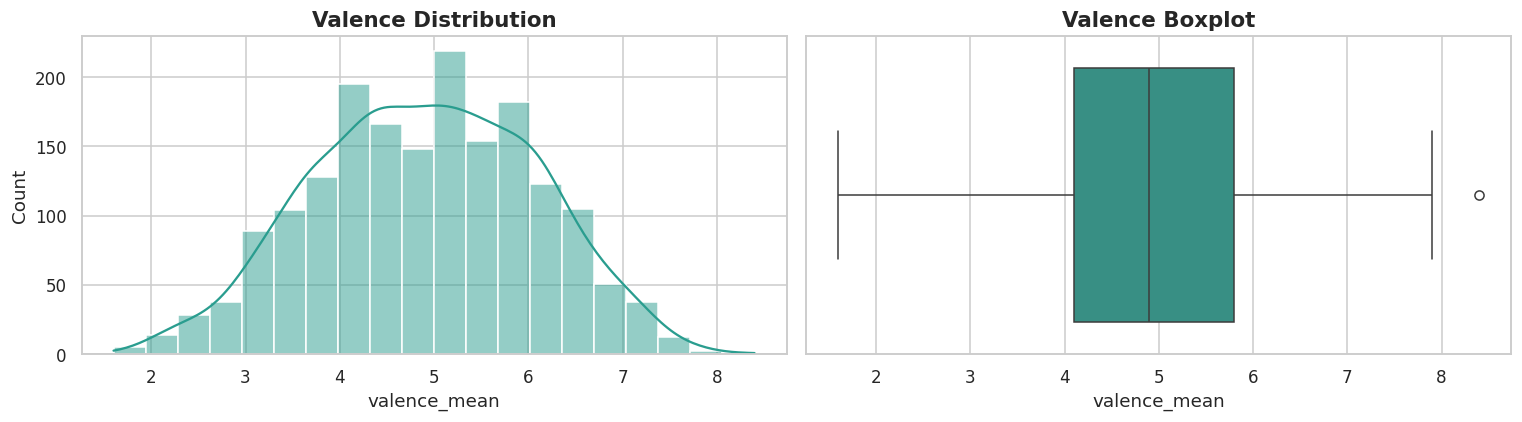

,song_id,valence_mean,arousal_mean,audio_path
402,488,1.6,3.4,/kaggle/input/datasets/imsparsh/deam-mediaeval...
320,375,1.9,2.8,/kaggle/input/datasets/imsparsh/deam-mediaeval...
397,482,1.9,3.5,/kaggle/input/datasets/imsparsh/deam-mediaeval...
323,379,1.9,2.9,/kaggle/input/datasets/imsparsh/deam-mediaeval...
166,198,1.9,3.3,/kaggle/input/datasets/imsparsh/deam-mediaeval...


In [16]:
valence_stats = plot_target_distribution(analysis_df, "valence_mean", "#2a9d8f", "Valence")
display(analysis_df.sort_values("valence_mean").head(5)[["song_id", "valence_mean", "arousal_mean", "audio_path"]])


Arousal summary:
count    1802.000000
mean        4.814029
std         1.282187
min         1.600000
25%         3.800000
50%         4.900000
75%         5.800000
max         8.100000
Name: arousal_mean, dtype: float64


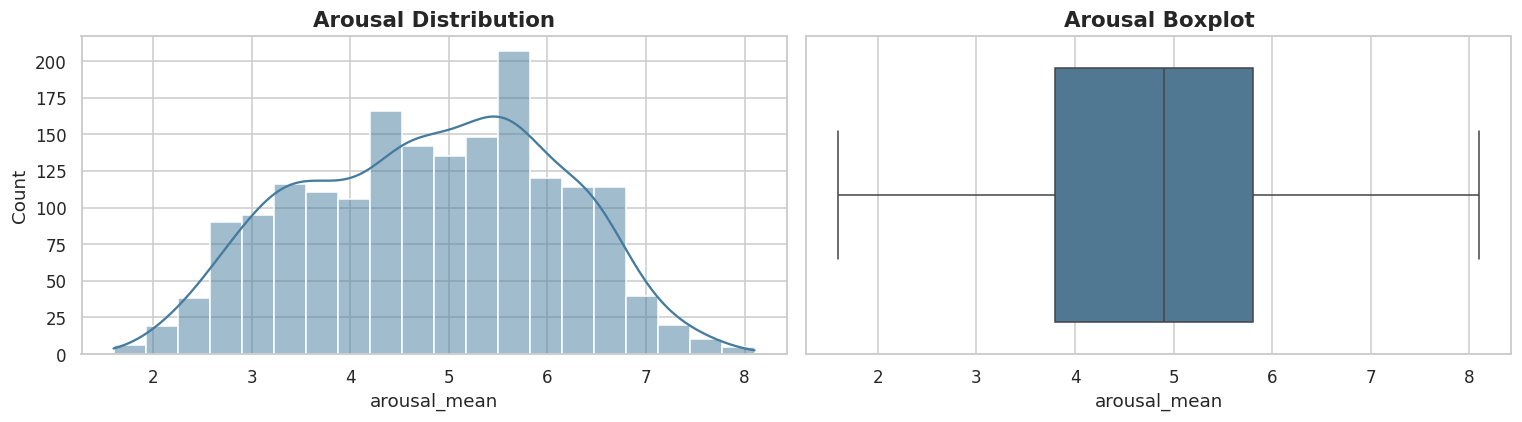

,song_id,valence_mean,arousal_mean,audio_path
583,745,4.2,1.6,/kaggle/input/datasets/imsparsh/deam-mediaeval...
941,1198,3.5,1.8,/kaggle/input/datasets/imsparsh/deam-mediaeval...
914,1171,3.6,1.9,/kaggle/input/datasets/imsparsh/deam-mediaeval...
759,1016,3.3,1.9,/kaggle/input/datasets/imsparsh/deam-mediaeval...
861,1118,4.0,1.9,/kaggle/input/datasets/imsparsh/deam-mediaeval...


In [17]:
arousal_stats = plot_target_distribution(analysis_df, "arousal_mean", "#457b9d", "Arousal")
display(analysis_df.sort_values("arousal_mean").head(5)[["song_id", "valence_mean", "arousal_mean", "audio_path"]])


## 6. Joint Valence-Arousal Analysis

This section looks at how the two targets relate to each other without turning the regression problem into a classification task.


Pearson correlation between valence_mean and arousal_mean: 0.5700


,valence_mean,arousal_mean,valence_std,arousal_std
valence_mean,1.000000,0.570026,-0.144784,0.024428
arousal_mean,0.570026,1.000000,0.004320,0.056897
valence_std,-0.144784,0.004320,1.000000,0.335732
arousal_std,0.024428,0.056897,0.335732,1.000000


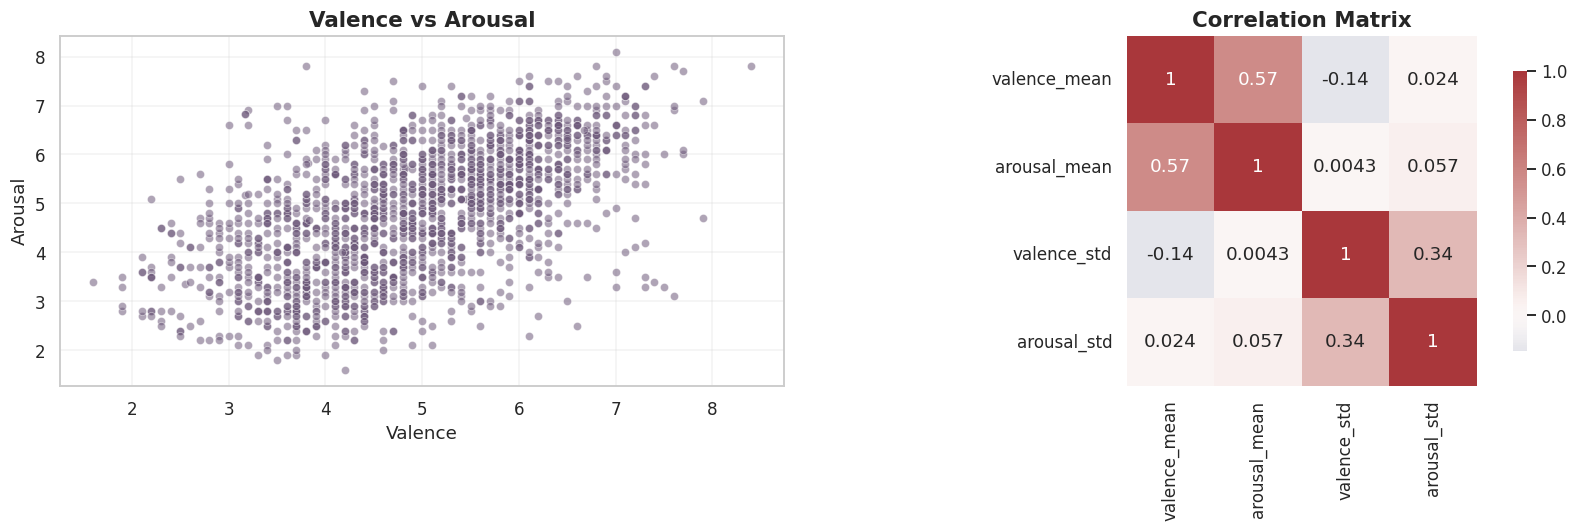

In [18]:
corr_cols = ["valence_mean", "arousal_mean", "valence_std", "arousal_std"]
corr_matrix = analysis_df[corr_cols].corr()
valence_arousal_corr = analysis_df["valence_mean"].corr(analysis_df["arousal_mean"])

print(f"Pearson correlation between valence_mean and arousal_mean: {valence_arousal_corr:.4f}")
display(corr_matrix)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(
    data=analysis_df,
    x="valence_mean",
    y="arousal_mean",
    alpha=0.55,
    s=28,
    color="#6d597a",
    ax=axes[0],
)
axes[0].set_title("Valence vs Arousal")
axes[0].set_xlabel("Valence")
axes[0].set_ylabel("Arousal")
axes[0].grid(alpha=0.25)

sns.heatmap(corr_matrix, annot=True, cmap="vlag", center=0, square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 7. Class/Emotion Space Exploration

The emotion space is still treated as continuous regression targets. The quadrants below are only used to visualize how samples occupy the valence-arousal plane.


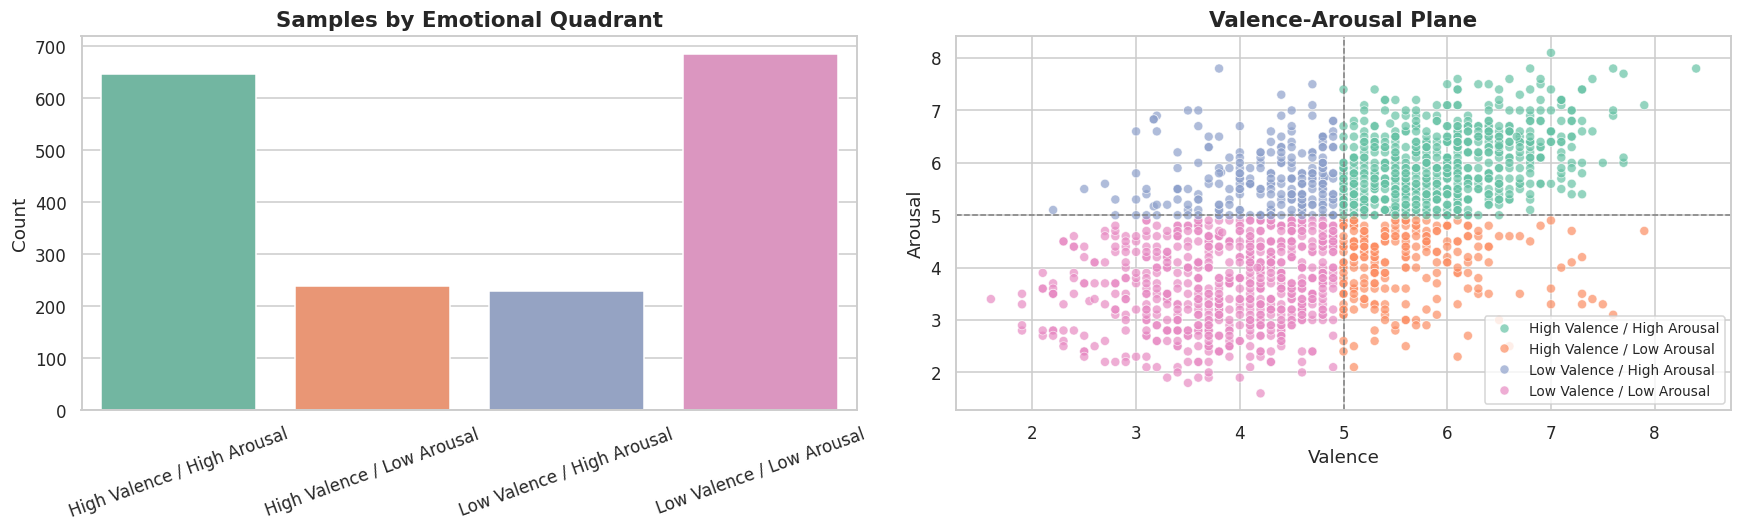

,count
emotion_quadrant,
High Valence / High Arousal,647
High Valence / Low Arousal,240
Low Valence / High Arousal,229
Low Valence / Low Arousal,686


In [20]:
neutral_point = 5.0

analysis_df = analysis_df.copy()
analysis_df["emotion_quadrant"] = np.select(
    [
        (analysis_df["valence_mean"] >= neutral_point) & (analysis_df["arousal_mean"] >= neutral_point),
        (analysis_df["valence_mean"] >= neutral_point) & (analysis_df["arousal_mean"] < neutral_point),
        (analysis_df["valence_mean"] < neutral_point) & (analysis_df["arousal_mean"] >= neutral_point),
        (analysis_df["valence_mean"] < neutral_point) & (analysis_df["arousal_mean"] < neutral_point),
    ],
    [
        "High Valence / High Arousal",
        "High Valence / Low Arousal",
        "Low Valence / High Arousal",
        "Low Valence / Low Arousal",
    ],
    default="Unclassified",
)

quadrant_order = [
    "High Valence / High Arousal",
    "High Valence / Low Arousal",
    "Low Valence / High Arousal",
    "Low Valence / Low Arousal",
]
quadrant_counts = analysis_df["emotion_quadrant"].value_counts().reindex(quadrant_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=quadrant_counts.index, y=quadrant_counts.values, palette="Set2", ax=axes[0])
axes[0].set_title("Samples by Emotional Quadrant")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)

sns.scatterplot(
    data=analysis_df,
    x="valence_mean",
    y="arousal_mean",
    hue="emotion_quadrant",
    hue_order=quadrant_order,
    palette="Set2",
    alpha=0.7,
    s=35,
    ax=axes[1],
)
axes[1].axvline(neutral_point, color="gray", linestyle="--", linewidth=1)
axes[1].axhline(neutral_point, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Valence-Arousal Plane")
axes[1].set_xlabel("Valence")
axes[1].set_ylabel("Arousal")
axes[1].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

display(quadrant_counts.to_frame(name="count"))


## 8. Audio-Level Exploratory Analysis

This section inspects a representative subset of audio files to keep the notebook light while still showing duration, sample rate, and mel-spectrogram scale.


Sampled audio files analyzed: 25


,song_id,sample_rate,duration_sec,mel_frames,valence_mean,arousal_mean
0,2048,44100,151.902041,33495,6.2,3.6
1,378,44100,45.060998,9936,5.5,5.9
2,1290,44100,45.000023,9923,6.6,6.6
3,194,44100,45.060998,9936,2.7,4.7
4,1530,44100,45.000023,9923,6.2,4.2


,duration_sec,mel_frames,sample_rate
count,25.000000,25.000000,25.0
mean,54.811112,12086.320000,44100.0
std,34.198835,7540.855106,0.0
min,45.000023,9923.000000,44100.0
25%,45.000023,9923.000000,44100.0
50%,45.000023,9923.000000,44100.0
75%,45.047778,9934.000000,44100.0
max,183.013878,40355.000000,44100.0


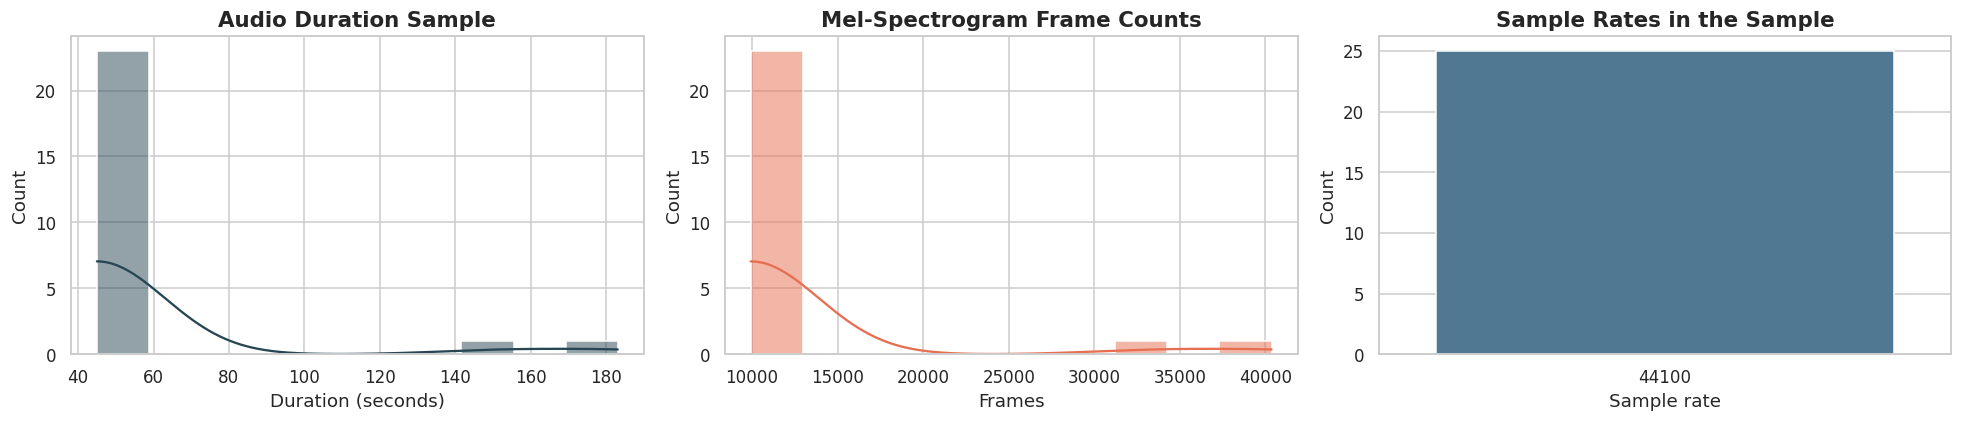

In [21]:
valid_audio_df = analysis_df[analysis_df["audio_exists"]].copy()
sample_size = min(25, len(valid_audio_df))
eda_audio_sample = valid_audio_df.sample(n=sample_size, random_state=42).copy() if sample_size > 0 else valid_audio_df.copy()

audio_records = []
for _, row in eda_audio_sample.iterrows():
    waveform, sample_rate, duration_sec, mel_db = summarize_audio_file(row["audio_path"])
    audio_records.append(
        {
            "song_id": row["song_id"],
            "audio_path": row["audio_path"],
            "sample_rate": sample_rate,
            "duration_sec": duration_sec,
            "mel_frames": mel_db.shape[1],
            "valence_mean": row["valence_mean"],
            "arousal_mean": row["arousal_mean"],
        }
    )

audio_summary_df = pd.DataFrame(audio_records)
print("Sampled audio files analyzed:", len(audio_summary_df))
if not audio_summary_df.empty:
    display(audio_summary_df[["song_id", "sample_rate", "duration_sec", "mel_frames", "valence_mean", "arousal_mean"]].head())
    display(audio_summary_df[["duration_sec", "mel_frames", "sample_rate"]].describe())

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(audio_summary_df["duration_sec"], bins=10, kde=True, color="#264653", ax=axes[0])
    axes[0].set_title("Audio Duration Sample")
    axes[0].set_xlabel("Duration (seconds)")
    axes[0].set_ylabel("Count")

    sns.histplot(audio_summary_df["mel_frames"], bins=10, kde=True, color="#e76f51", ax=axes[1])
    axes[1].set_title("Mel-Spectrogram Frame Counts")
    axes[1].set_xlabel("Frames")
    axes[1].set_ylabel("Count")

    sr_counts = audio_summary_df["sample_rate"].value_counts().sort_index()
    sns.barplot(x=sr_counts.index.astype(str), y=sr_counts.values, color="#457b9d", ax=axes[2])
    axes[2].set_title("Sample Rates in the Sample")
    axes[2].set_xlabel("Sample rate")
    axes[2].set_ylabel("Count")

    plt.tight_layout()
    plt.show()
else:
    print("No valid audio files were available for the sample-based audio analysis.")


## 9. Representative Audio Examples

The examples below connect the raw audio, the mel-spectrogram representation, and the corresponding valence-arousal labels.


High Valence / High Arousal
song_id: 4
valence_mean: 5.70
arousal_mean: 5.50
audio_path: /kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/4.mp3


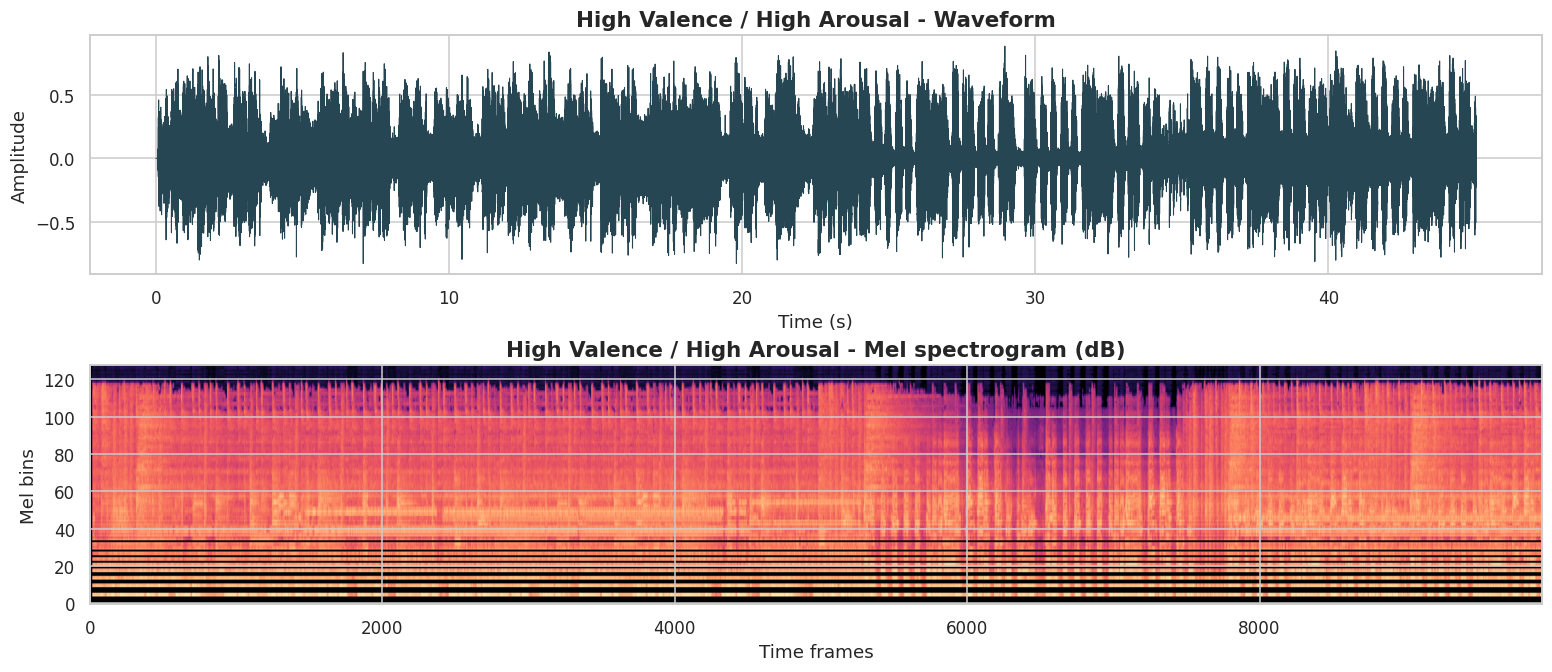

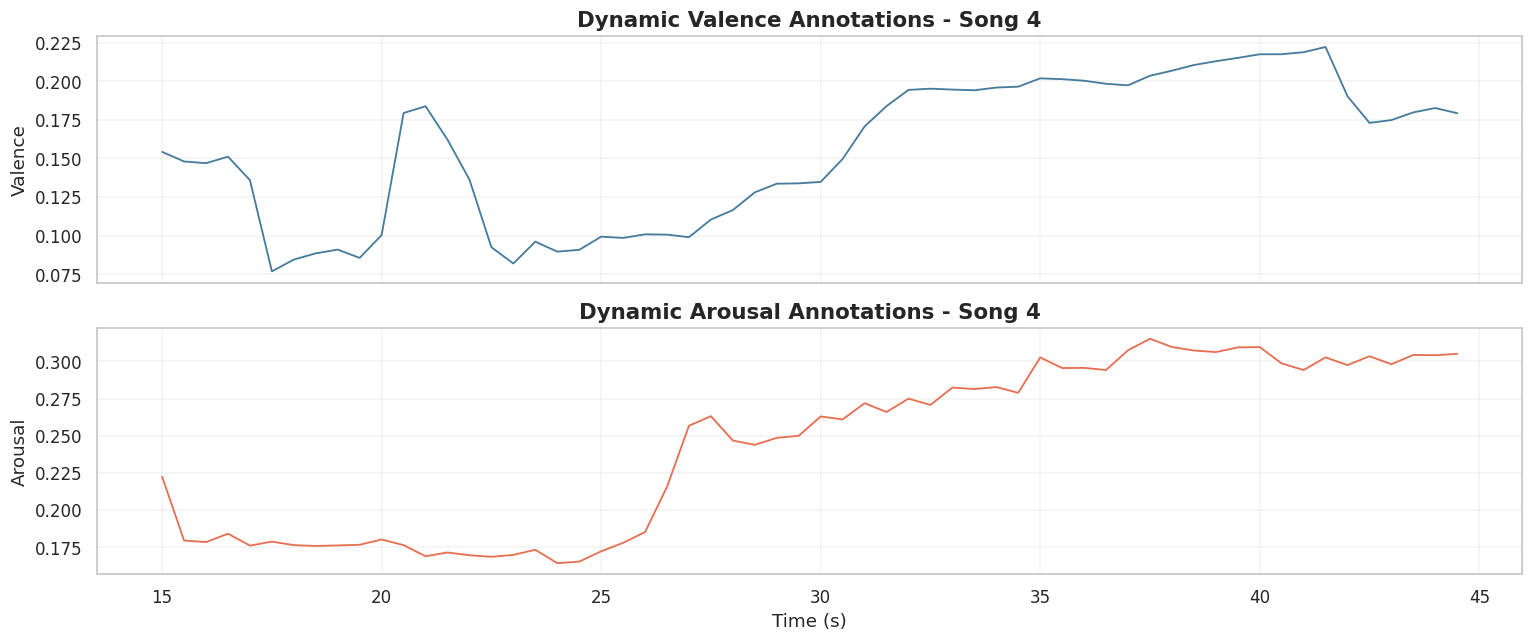

--------------------------------------------------------------------------------
Low Valence / Low Arousal
song_id: 2
valence_mean: 3.10
arousal_mean: 3.00
audio_path: /kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/2.mp3


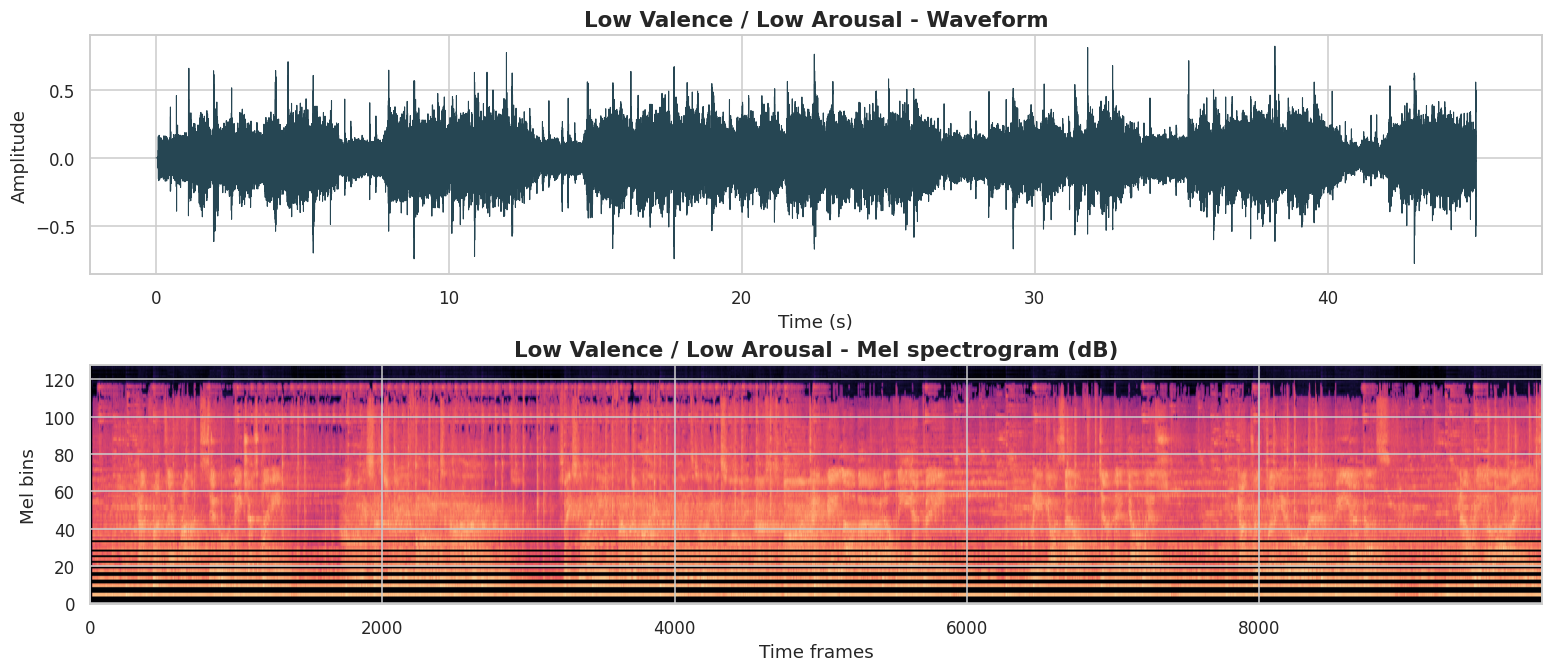

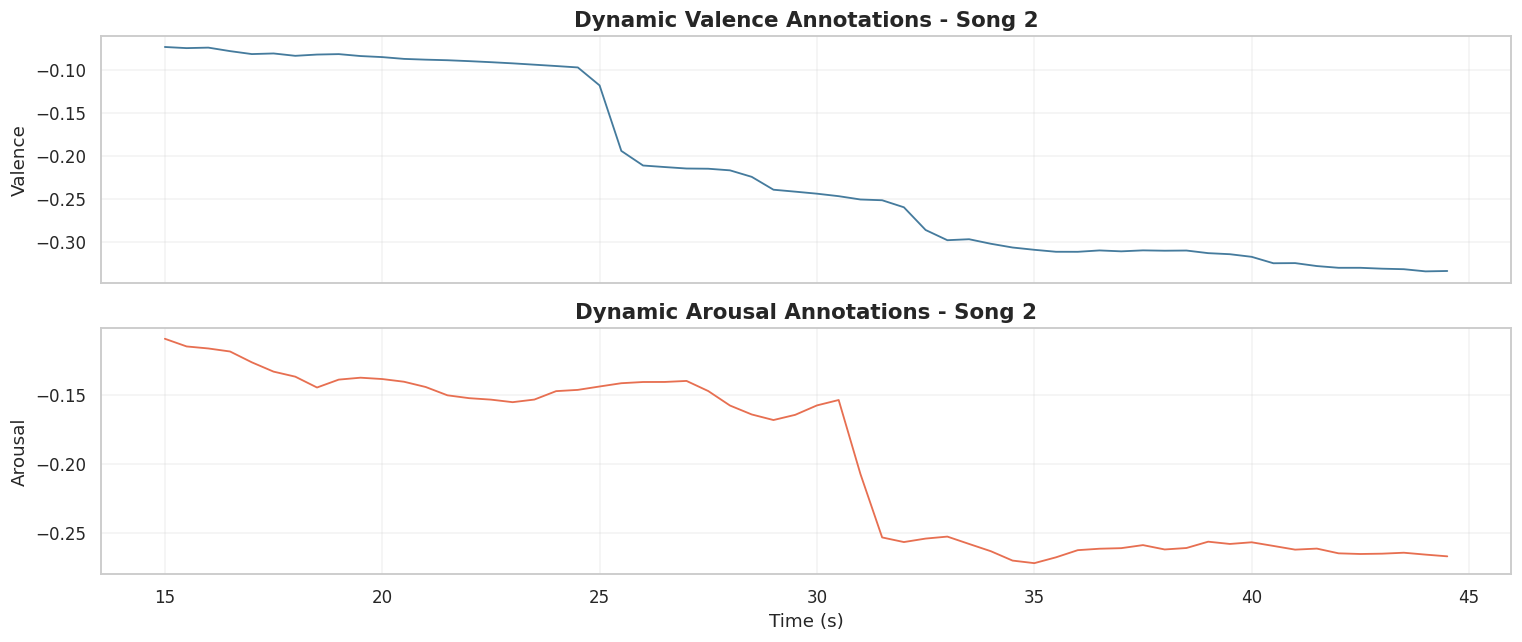

--------------------------------------------------------------------------------
Closest to Neutral Point
song_id: 1812
valence_mean: 5.00
arousal_mean: 5.00
audio_path: /kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1812.mp3


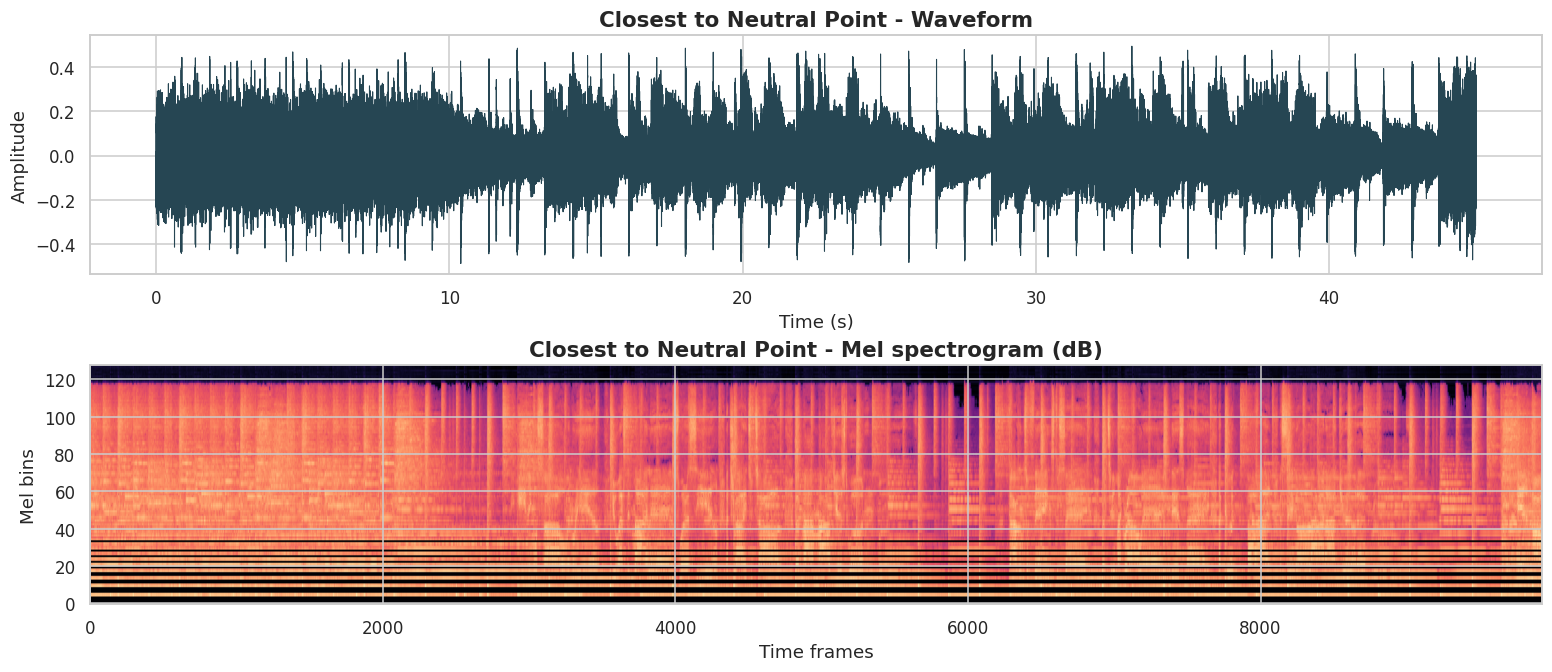

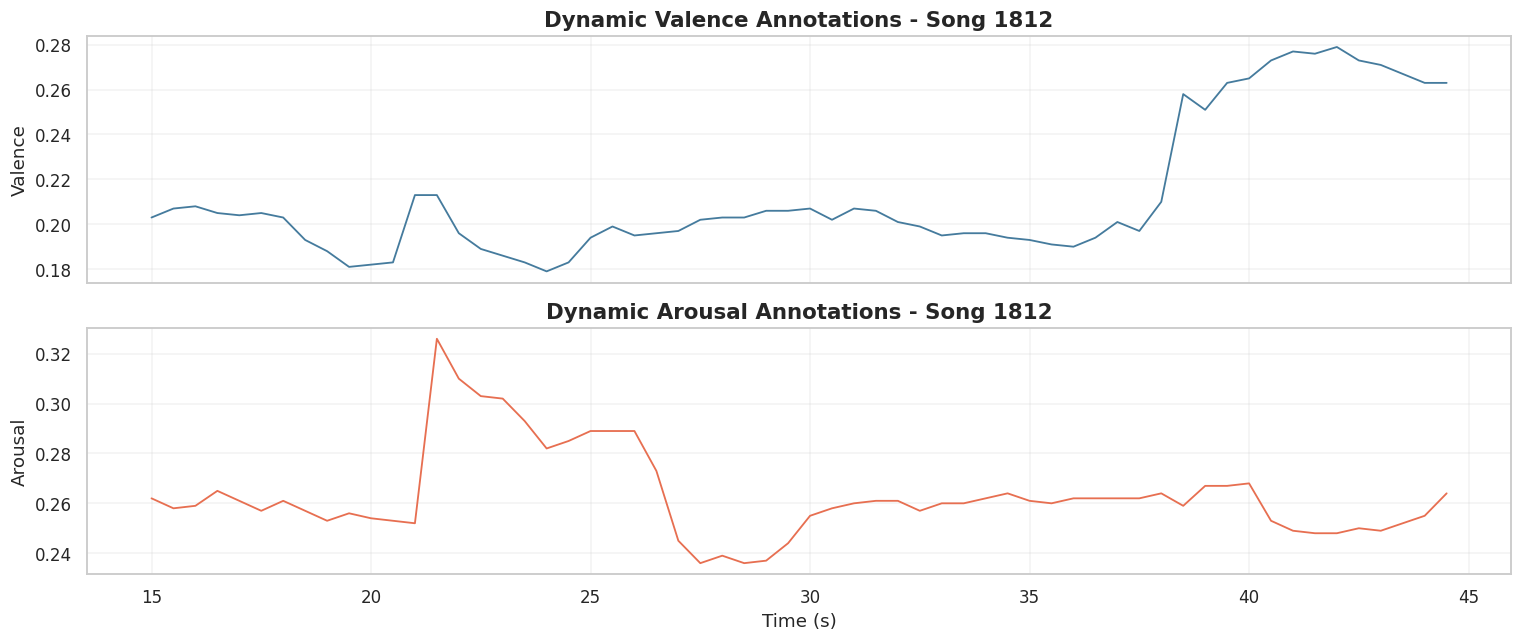

--------------------------------------------------------------------------------


In [22]:
def plot_audio_example(row, example_title):
    waveform, sample_rate = load_audio_mono(row["audio_path"])
    duration_sec = waveform.numel() / sample_rate
    mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate)
    db_transform = torchaudio.transforms.AmplitudeToDB()
    mel_db = db_transform(mel_transform(waveform))

    time_axis = np.linspace(0, duration_sec, waveform.numel())
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), constrained_layout=True)
    axes[0].plot(time_axis, waveform.numpy(), color="#264653", linewidth=0.7)
    axes[0].set_title(f"{example_title} - Waveform")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")

    axes[1].imshow(mel_db.numpy(), aspect="auto", origin="lower", cmap="magma")
    axes[1].set_title(f"{example_title} - Mel spectrogram (dB)")
    axes[1].set_xlabel("Time frames")
    axes[1].set_ylabel("Mel bins")

    plt.show()
    display(Audio(row["audio_path"]))

candidate_examples = {
    "High Valence / High Arousal": analysis_df[
        (analysis_df["emotion_quadrant"] == "High Valence / High Arousal") & analysis_df["audio_exists"]
    ],
    "Low Valence / Low Arousal": analysis_df[
        (analysis_df["emotion_quadrant"] == "Low Valence / Low Arousal") & analysis_df["audio_exists"]
    ],
    "Closest to Neutral Point": analysis_df[
        analysis_df["audio_exists"]
    ].assign(
        distance_to_neutral=lambda frame: (frame["valence_mean"] - neutral_point) ** 2 + (frame["arousal_mean"] - neutral_point) ** 2
    ).sort_values("distance_to_neutral"),
}

for example_name, subset in candidate_examples.items():
    if subset.empty:
        print(f"No available example for {example_name}.")
        continue

    row = subset.iloc[0]
    print(f"{example_name}")
    print(f"song_id: {int(row['song_id'])}")
    print(f"valence_mean: {row['valence_mean']:.2f}")
    print(f"arousal_mean: {row['arousal_mean']:.2f}")
    print(f"audio_path: {row['audio_path']}")
    plot_audio_example(row, example_name)

    dynamic_valence_row = dynamic_annotations_valence[dynamic_annotations_valence["song_id"] == int(row["song_id"])]
    dynamic_arousal_row = dynamic_annotations_arousal[dynamic_annotations_arousal["song_id"] == int(row["song_id"])]

    if not dynamic_valence_row.empty and not dynamic_arousal_row.empty:
        time_columns = [col for col in dynamic_valence_row.columns if col.startswith("sample_")]
        time_values = np.array([int(col.split("_")[1][:-2]) / 1000 for col in time_columns])
        valence_values = dynamic_valence_row[time_columns].iloc[0].to_numpy(dtype=float)
        arousal_values = dynamic_arousal_row[time_columns].iloc[0].to_numpy(dtype=float)

        fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        axes[0].plot(time_values, valence_values, color="#457b9d", linewidth=1.2)
        axes[0].set_title(f"Dynamic Valence Annotations - Song {int(row['song_id'])}")
        axes[0].set_ylabel("Valence")
        axes[0].grid(alpha=0.25)

        axes[1].plot(time_values, arousal_values, color="#e76f51", linewidth=1.2)
        axes[1].set_title(f"Dynamic Arousal Annotations - Song {int(row['song_id'])}")
        axes[1].set_xlabel("Time (s)")
        axes[1].set_ylabel("Arousal")
        axes[1].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()
    else:
        print("Dynamic annotations were not available for this song_id.")

    print("-" * 80)


## 10. Key EDA Findings

The final summary below is generated from the computations above so that the conclusions remain tied to the actual dataset in this notebook run.


In [23]:
valid_audio_count = int(labels_df["audio_exists"].sum())
invalid_audio_count = int((~labels_df["audio_exists"]).sum())
quadrant_share = quadrant_counts / quadrant_counts.sum()
dominant_quadrant = quadrant_share.idxmax()
dominant_share = quadrant_share.max()
duration_mean = audio_summary_df["duration_sec"].mean() if not audio_summary_df.empty else np.nan
duration_median = audio_summary_df["duration_sec"].median() if not audio_summary_df.empty else np.nan
sample_rate_mode = int(audio_summary_df["sample_rate"].mode().iloc[0]) if not audio_summary_df.empty else None

print("Key findings")
print(f"- The loaded labels_df contains {len(labels_df)} rows, and {len(analysis_df)} unique song_ids are used for analysis after duplicate-safe de-duplication.")
print(f"- Audio files resolved on disk for {valid_audio_count} rows; {invalid_audio_count} rows did not resolve to a file path.")
print(f"- Valence summary: min={analysis_df['valence_mean'].min():.2f}, median={analysis_df['valence_mean'].median():.2f}, max={analysis_df['valence_mean'].max():.2f}.")
print(f"- Arousal summary: min={analysis_df['arousal_mean'].min():.2f}, median={analysis_df['arousal_mean'].median():.2f}, max={analysis_df['arousal_mean'].max():.2f}.")
print(f"- Pearson correlation between valence and arousal is {valence_arousal_corr:.4f}, so the relationship can be inspected but should not be overinterpreted.")
print(f"- The largest exploratory quadrant is '{dominant_quadrant}' with {dominant_share:.1%} of the analyzed songs.")
if not audio_summary_df.empty:
    print(f"- In the sampled audio subset, the mean duration is {duration_mean:.2f} seconds and the median duration is {duration_median:.2f} seconds.")
    print(f"- The most common sample rate in the sampled subset is {sample_rate_mode} Hz.")
print("- The notebook includes representative waveform, mel-spectrogram, and dynamic annotation views to connect the raw audio with the regression targets.")


Key findings
- The loaded labels_df contains 1802 rows, and 1802 unique song_ids are used for analysis after duplicate-safe de-duplication.
- Audio files resolved on disk for 1802 rows; 0 rows did not resolve to a file path.
- Valence summary: min=1.60, median=4.90, max=8.40.
- Arousal summary: min=1.60, median=4.90, max=8.10.
- Pearson correlation between valence and arousal is 0.5700, so the relationship can be inspected but should not be overinterpreted.
- The largest exploratory quadrant is 'Low Valence / Low Arousal' with 38.1% of the analyzed songs.
- In the sampled audio subset, the mean duration is 54.81 seconds and the median duration is 45.00 seconds.
- The most common sample rate in the sampled subset is 44100 Hz.
- The notebook includes representative waveform, mel-spectrogram, and dynamic annotation views to connect the raw audio with the regression targets.
